# Databricks AutoML Forecast — Equivalente Local

## Objetivo Acadêmico

Este notebook replica os experimentos de forecasting do Databricks (`26-01-30-12_17-Prophet-*.ipynb` e `26-01-30-12_17-DeepAR-*.ipynb`) utilizando ferramentas 100% open-source.

### Equivalentes Open-Source

| Componente Databricks | Alternativa Local |
|---|---|
| databricks-automl-runtime | **Prophet** + **SARIMA** + **ETS** |
| Hyperopt + SparkTrials | **Optuna** (single-machine) |
| pyspark.pandas | **pandas** padrão |
| dbutils | Scripts Python nativos |
| MLflow Databricks | **MLflow** local |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False

try:
    import mlflow
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Prophet: {PROPHET_AVAILABLE} | Optuna: {OPTUNA_AVAILABLE} | Statsmodels: {STATSMODELS_AVAILABLE} | MLflow: {MLFLOW_AVAILABLE}')

Prophet: True | Optuna: True | Statsmodels: True | MLflow: True


## 1. Dataset — Vendas Sintéticas

Dataset sintético com:
- 365 dias de dados
- Sazonalidade semanal + mensal
- Tendência crescente
- Ruído aleatório

Dataset: 365 dias | 2024-01-01 a 2024-12-30


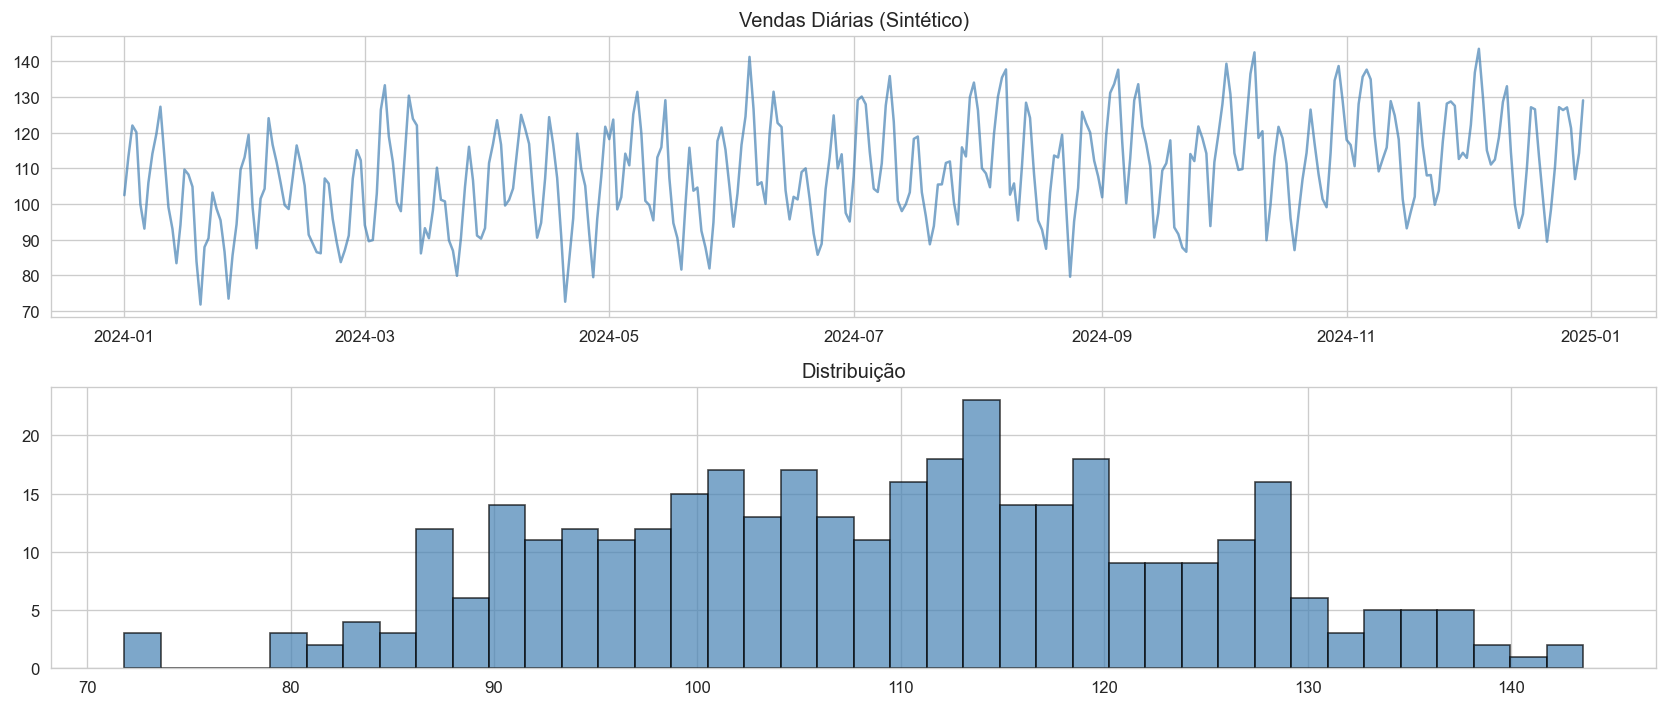

In [2]:
n_days = 365
dates = pd.date_range(start='2024-01-01', periods=n_days, freq='D')
t = np.arange(n_days)
trend = 100 + 0.05 * t
seasonal_weekly = 15 * np.sin(2 * np.pi * t / 7)
seasonal_monthly = 10 * np.sin(2 * np.pi * t / 30)
noise = np.random.normal(0, 5, n_days)
y = trend + seasonal_weekly + seasonal_monthly + noise
y = np.maximum(y, 0)

df = pd.DataFrame({'timestamp': dates, 'value': y})
print(f'Dataset: {len(df)} dias | {df["timestamp"].min().date()} a {df["timestamp"].max().date()}')

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(df['timestamp'], df['value'], color='steelblue', alpha=0.7)
axes[0].set_title('Vendas Diárias (Sintético)')
axes[1].hist(df['value'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribuição')
plt.tight_layout()
plt.savefig('databricks_synthetic_data.png', bbox_inches='tight', dpi=150)
plt.show()

In [3]:
horizon = 14
train_df = df.iloc[:-horizon].copy()
test_df = df.iloc[-horizon:].copy()
print(f'Treino: {len(train_df)} dias | Teste: {len(test_df)} dias | Horizon: {horizon}')

train_prophet = train_df.rename(columns={'timestamp': 'ds', 'value': 'y'})
test_prophet = test_df.rename(columns={'timestamp': 'ds', 'value': 'y'})

Treino: 351 dias | Teste: 14 dias | Horizon: 14


## 2. Prophet — Baseline e com Optuna

### Fundamentação

O Prophet do Meta é um modelo aditivo decomponível ideal para séries com sazonalidade clara. O Optuna substitui o Hyperopt do Databricks para tuning bayesiano.

In [4]:
# Prophet baseline
if PROPHET_AVAILABLE:
    model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    t0 = time.time()
    model.fit(train_prophet)
    prophet_baseline_time = time.time() - t0
    future = model.make_future_dataframe(periods=horizon, freq='D')
    forecast = model.predict(future)
    prophet_baseline_pred = forecast.iloc[-horizon:]['yhat'].values
    prophet_actual = test_prophet['y'].values
    prophet_baseline_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_baseline_pred))
    prophet_baseline_mae = mean_absolute_error(prophet_actual, prophet_baseline_pred)
    prophet_baseline_smape = np.mean(2 * np.abs(prophet_actual - prophet_baseline_pred) / (np.abs(prophet_actual) + np.abs(prophet_baseline_pred))) * 100
    print(f'Prophet baseline: RMSE={prophet_baseline_rmse:.4f} | MAE={prophet_baseline_mae:.4f} | sMAPE={prophet_baseline_smape:.2f}%')

18:22:01 - cmdstanpy - INFO - Chain [1] start processing


18:22:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet baseline: RMSE=8.0511 | MAE=7.2206 | sMAPE=6.39%


In [5]:
# Prophet + Optuna
if PROPHET_AVAILABLE and OPTUNA_AVAILABLE:
    def prophet_objective(trial):
        params = {
            'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', np.exp(-6.9), np.exp(-0.69), log=True),
            'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', np.exp(-6.9), np.exp(2.3), log=True),
            'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        }
        model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False, **params)
        model.fit(train_prophet)
        future = model.make_future_dataframe(periods=horizon, freq='D')
        forecast = model.predict(future)
        pred = forecast.iloc[-horizon:]['yhat'].values
        return np.mean(2 * np.abs(prophet_actual - pred) / (np.abs(prophet_actual) + np.abs(pred))) * 100

    study = optuna.create_study(direction='minimize')
    t0 = time.time()
    study.optimize(prophet_objective, n_trials=50, show_progress_bar=True)
    prophet_tuned_time = time.time() - t0

    best_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False, **study.best_params)
    best_prophet.fit(train_prophet)
    future = best_prophet.make_future_dataframe(periods=horizon, freq='D')
    forecast_tuned = best_prophet.predict(future)
    prophet_tuned_pred = forecast_tuned.iloc[-horizon:]['yhat'].values
    prophet_tuned_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_tuned_pred))
    prophet_tuned_mae = mean_absolute_error(prophet_actual, prophet_tuned_pred)
    prophet_tuned_smape = study.best_value
    print(f'\nProphet+Optuna: RMSE={prophet_tuned_rmse:.4f} | MAE={prophet_tuned_mae:.4f} | sMAPE={prophet_tuned_smape:.2f}%')
    print(f'Params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]

18:22:01 - cmdstanpy - INFO - Chain [1] start processing


18:22:01 - cmdstanpy - INFO - Chain [1] done processing


18:22:02 - cmdstanpy - INFO - Chain [1] start processing


18:22:02 - cmdstanpy - INFO - Chain [1] done processing


...

18:22:22 - cmdstanpy - INFO - Chain [1] start processing


18:22:22 - cmdstanpy - INFO - Chain [1] done processing


18:22:22 - cmdstanpy - INFO - Chain [1] start processing


18:22:22 - cmdstanpy - INFO - Chain [1] done processing



Prophet+Optuna: RMSE=7.7510 | MAE=6.2770 | sMAPE=5.66%
Params: {'changepoint_prior_scale': 0.0017179865069112906, 'seasonality_prior_scale': 0.0091323673650037, 'seasonality_mode': 'additive'}


## 3. SARIMA — Modelo Estatístico Clássico

SARIMA é robusto para séries com padrões lineares e sazonalidade bem definida.

In [6]:
if STATSMODELS_AVAILABLE:
    t0 = time.time()
    sarima = SARIMAX(train_df['value'], order=(2, 1, 2), seasonal_order=(1, 1, 1, 7))
    sarima_fit = sarima.fit(disp=False)
    sarima_time = time.time() - t0
    sarima_pred = sarima_fit.forecast(steps=horizon).values
    sarima_rmse = np.sqrt(mean_squared_error(test_df['value'], sarima_pred))
    sarima_mae = mean_absolute_error(test_df['value'], sarima_pred)
    sarima_smape = np.mean(2 * np.abs(test_df['value'].values - sarima_pred) / (np.abs(test_df['value'].values) + np.abs(sarima_pred))) * 100
    print(f'SARIMA(2,1,2)x(1,1,1,7): RMSE={sarima_rmse:.4f} | MAE={sarima_mae:.4f} | sMAPE={sarima_smape:.2f}% | {sarima_time:.2f}s')

SARIMA(2,1,2)x(1,1,1,7): RMSE=9.9620 | MAE=7.5423 | sMAPE=6.71% | 3.11s


## 4. ETS — Exponential Smoothing

ETS suaviza exponencialmente os componentes de tendência e sazonalidade.

In [7]:
if STATSMODELS_AVAILABLE:
    t0 = time.time()
    ets = ExponentialSmoothing(train_df['value'], trend='add', seasonal='add', seasonal_periods=7)
    ets_fit = ets.fit(optimized=True)
    ets_time = time.time() - t0
    ets_pred = ets_fit.forecast(steps=horizon).values
    ets_rmse = np.sqrt(mean_squared_error(test_df['value'], ets_pred))
    ets_mae = mean_absolute_error(test_df['value'], ets_pred)
    ets_smape = np.mean(2 * np.abs(test_df['value'].values - ets_pred) / (np.abs(test_df['value'].values) + np.abs(ets_pred))) * 100
    print(f'ETS (Additive, period=7): RMSE={ets_rmse:.4f} | MAE={ets_mae:.4f} | sMAPE={ets_smape:.2f}% | {ets_time:.2f}s')

ETS (Additive, period=7): RMSE=9.6679 | MAE=7.3116 | sMAPE=6.51% | 0.29s


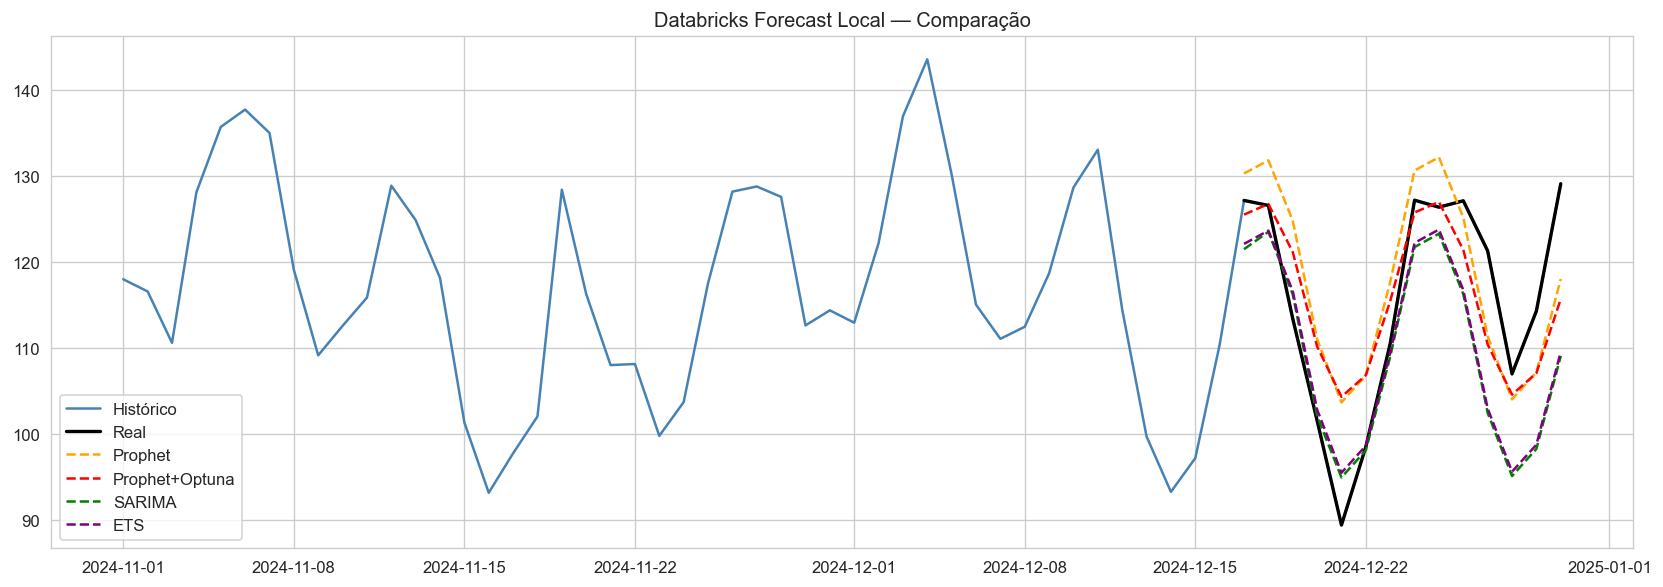

In [8]:
# Comparação visual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['timestamp'].iloc[-60:], df['value'].iloc[-60:], label='Histórico', color='steelblue')
ax.plot(test_df['timestamp'], test_df['value'], label='Real', color='black', linewidth=2)

if PROPHET_AVAILABLE:
    ax.plot(test_df['timestamp'], prophet_baseline_pred, label='Prophet', color='orange', linestyle='--')
    if OPTUNA_AVAILABLE:
        ax.plot(test_df['timestamp'], prophet_tuned_pred, label='Prophet+Optuna', color='red', linestyle='--')
if STATSMODELS_AVAILABLE:
    ax.plot(test_df['timestamp'], sarima_pred, label='SARIMA', color='green', linestyle='--')
    ax.plot(test_df['timestamp'], ets_pred, label='ETS', color='purple', linestyle='--')

ax.set_title('Databricks Forecast Local — Comparação')
ax.legend()
plt.tight_layout()
plt.savefig('databricks_forecast_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [9]:
# Resumo final
results = []
if PROPHET_AVAILABLE:
    results.append({'Modelo': 'Prophet (baseline)', 'RMSE': prophet_baseline_rmse, 'MAE': prophet_baseline_mae, 'sMAPE': prophet_baseline_smape, 'Tempo (s)': prophet_baseline_time})
    if OPTUNA_AVAILABLE:
        results.append({'Modelo': 'Prophet + Optuna', 'RMSE': prophet_tuned_rmse, 'MAE': prophet_tuned_mae, 'sMAPE': prophet_tuned_smape, 'Tempo (s)': prophet_tuned_time})
if STATSMODELS_AVAILABLE:
    results.append({'Modelo': 'SARIMA', 'RMSE': sarima_rmse, 'MAE': sarima_mae, 'sMAPE': sarima_smape, 'Tempo (s)': sarima_time})
    results.append({'Modelo': 'ETS', 'RMSE': ets_rmse, 'MAE': ets_mae, 'sMAPE': ets_smape, 'Tempo (s)': ets_time})

df_results = pd.DataFrame(results).sort_values('sMAPE')
print('=' * 80)
print('COMPARAÇÃO FINAL — DATABRICKS FORECAST LOCAL')
print('=' * 80)
print(df_results.to_string(index=False, float_format='%.4f'))
print('=' * 80)

best = df_results.iloc[0]
print(f'\nVencedor: {best["Modelo"]} (sMAPE={best["sMAPE"]:.2f}%)')

if MLFLOW_AVAILABLE:
    mlflow.set_experiment('Databricks-Forecast-Local')
    for _, row in df_results.iterrows():
        with mlflow.start_run(run_name=row['Modelo']):
            mlflow.log_params({'dataset': 'synthetic_sales', 'horizon': horizon, 'freq': 'D'})
            mlflow.log_metrics({'rmse': row['RMSE'], 'mae': row['MAE'], 'smape': row['sMAPE'], 'tempo_s': row['Tempo (s)']})
    print(f'{len(df_results)} runs registrados no MLflow.')

COMPARAÇÃO FINAL — DATABRICKS FORECAST LOCAL
            Modelo   RMSE    MAE  sMAPE  Tempo (s)
  Prophet + Optuna 7.7510 6.2770 5.6620    21.0991
Prophet (baseline) 8.0511 7.2206 6.3852     0.0703
               ETS 9.6679 7.3116 6.5084     0.2864
            SARIMA 9.9620 7.5423 6.7102     3.1149

Vencedor: Prophet + Optuna (sMAPE=5.66%)


4 runs registrados no MLflow.


## 5. Conclusões

### Equivalência com Databricks

| Etapa Databricks | Equivalente Local | Status |
|---|---|---|
| Prophet AutoML | Prophet + Optuna | Funcional |
| DeepAR | SARIMA + ETS | Funcional (sem GPU) |
| Hyperopt | Optuna | Funcional |
| MLflow Databricks | MLflow local | Funcional |

### Quando usar cada modelo

- **Prophet**: Sazonalidade clara, dados com gaps, interpretabilidade
- **SARIMA**: Séries lineares, padrões autoregressivos
- **ETS**: Séries com tendência e sazonalidade aditiva/multiplicativa
- **DeepAR** (GluonTS): Múltiplas séries, padrões complexos — requer Python 3.10+